# Dataset Pipeline: Bicycles vs. Motorcycles

**Step 1 of 2** in this project. Run this notebook first, then continue with
`project_pipeline.ipynb`.

This notebook merges two raw Kaggle datasets into one clean, de-duplicated
dataset for the binary classification task **bicycle vs. motorcycle**.

## Prerequisites

1. Download the two source datasets from Kaggle (see `00_instructions/` for
   the exact links and download steps) and unzip them into:
   ```
   01_data_raw/
   ├── archive (1)/   # first Kaggle dataset
   └── archive (2)/   # second Kaggle dataset
   ```
2. Make sure the folder names above match exactly — the paths are hard-coded
   in the configuration cell below (`SOURCE_DATASETS`).
3. Python 3.10/3.11 with the packages from `requirements.txt` installed
   (`Pillow`, `matplotlib`).

## Pipeline steps

1. Configuration of source and target folders
2. Scanning the source datasets for relevant classes
3. Validating the images (filtering out broken/empty files)
4. Duplicate detection via hashing (within and across datasets)
5. Copying into a new, unified structure
6. Overview and visualization

## Output

```
02_data_clean/
├── bicycle/
└── motorcycle/
```

This is the exact folder structure that `project_pipeline.ipynb` expects as
its input — do not rename these two class folders.

## 1. Imports & Configuration

In [1]:
# Standard library imports for hashing, file copying, paths and counting
import hashlib
import shutil
from pathlib import Path
from collections import defaultdict

# Pillow handles image validation; matplotlib is used for the final plots
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
# === ADJUST: Paths to two Kaggle datasets ===
# Each entry points to the root folder of one downloaded Kaggle archive.
SOURCE_DATASETS = [
    Path("01_data_raw/archive (1)"),
    Path("01_data_raw/archive (2)"),
]

# Target folder for the combined dataset (created later by the pipeline)
OUTPUT_DIR = Path("02_data_clean/")

# === ADJUST: Mapping from source folder names to our target classes ===
# Key   = folder name in the source datasets (lowercase)
# Value = target class in our new dataset
# Example: if one dataset has a folder 'Bike' and another has 'bicycle',
# we map both to 'bicycle'.
CLASS_MAPPING = {
    "bicycle": "bicycle",
    "Bicycle annotated": "bicycle",
    "motorcycle": "motorcycle"
}

# Allowed image file extensions; anything else is ignored
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Minimum resolution; images smaller than this in either dimension are dropped
MIN_SIZE = (32, 32)


## 2. Helper Functions

In [3]:
def file_hash(path: Path, chunk_size: int = 8192) -> str:
    """Computes the MD5 hash of a file for duplicate detection."""
    # Read the file in chunks so we don't load large images fully into memory
    h = hashlib.md5()
    with open(path, "rb") as f:
        while chunk := f.read(chunk_size):
            h.update(chunk)
    return h.hexdigest()


def is_valid_image(path: Path) -> bool:
    """Checks whether a file is a valid, non-corrupted image."""
    try:
        # First pass: verify the file's integrity (does not decode pixel data)
        with Image.open(path) as img:
            img.verify()  # checks integrity
        # Reopen for the size check (verify() leaves the image in an unusable state)
        with Image.open(path) as img:
            # Reject images that are too small to be useful for training
            if img.size[0] < MIN_SIZE[0] or img.size[1] < MIN_SIZE[1]:
                return False
        return True
    except Exception:
        # Any read/parse error means the file is not a usable image
        return False


def find_class_folders(dataset_root: Path) -> dict[str, list[Path]]:
    """Finds all relevant class folders inside a source dataset.

    Searches recursively (some Kaggle datasets use nested structures
    like train/bicycle, val/bicycle, etc.).
    """
    # Map target class name -> list of matching source folders
    found = defaultdict(list)
    if not dataset_root.exists():
        # Print a warning instead of raising so the pipeline can continue
        print(f"  [WARNING] Path does not exist: {dataset_root}")
        return found

    # rglob walks the whole tree; we keep only directories whose name is in the mapping
    for folder in dataset_root.rglob("*"):
        if folder.is_dir():
            folder_name = folder.name.lower().strip()
            if folder_name in CLASS_MAPPING:
                target_class = CLASS_MAPPING[folder_name]
                found[target_class].append(folder)
    return found


## 3. Inspect Source Datasets

Before we copy anything, let's see what is found in the source datasets. This lets us adjust the `CLASS_MAPPING` in case any classes are being missed.


In [4]:
# Walk through every configured source dataset and report what we found.
# This is a dry run: nothing is copied here.
for dataset_path in SOURCE_DATASETS:
    print(f"\n[Folder] {dataset_path}")
    class_folders = find_class_folders(dataset_path)
    if not class_folders:
        print("  No relevant class folders found!")
        # Helpful: list a few top-level folders so we can spot wrong mappings
        if dataset_path.exists():
            top_dirs = [p.name for p in dataset_path.iterdir() if p.is_dir()][:10]
            print(f"  Top-level folders: {top_dirs}")
        continue
    # Per target class, show how many folders contribute and roughly how many files they hold
    for target_class, folders in class_folders.items():
        total_files = sum(len(list(f.iterdir())) for f in folders)
        print(f"  -> {target_class}: {len(folders)} folders, ~{total_files} files")
        for f in folders:
            # Show the path relative to the dataset root for readability
            print(f"      {f.relative_to(dataset_path)}")



[Folder] 01_data_raw\archive (1)
  -> motorcycle: 1 folders, ~100 files
      Dataset\motorcycle

[Folder] 01_data_raw\archive (2)
  -> bicycle: 1 folders, ~180 files
      vehicle_data\bicycle
  -> motorcycle: 1 folders, ~192 files
      vehicle_data\motorcycle


**Note:** If classes are missing above or unexpected folder names show up, adjust the `CLASS_MAPPING` in cell 2 and re-run this cell.

## 4. Run the Pipeline

This cell does the real work:
- Iterates over every class folder we found
- Validates each image
- Computes a hash and skips duplicates
- Copies valid, unique images into the target folder
- Assigns unique filenames to avoid collisions between datasets


In [5]:
# Prepare the target folder.
# If it already exists we ask the user before deleting it, so we don't wipe
# work by accident.
if OUTPUT_DIR.exists():
    response = input(f"{OUTPUT_DIR} already exists. Delete and recreate? (yes/no): ")
    if response.lower() == "yes":
        shutil.rmtree(OUTPUT_DIR)
    else:
        # Abort hard rather than silently mixing old and new files
        raise RuntimeError("Aborted. Please clean up OUTPUT_DIR manually.")

# Create one subfolder per target class (e.g. bicycle/, motorcycle/)
for target_class in set(CLASS_MAPPING.values()):
    (OUTPUT_DIR / target_class).mkdir(parents=True, exist_ok=True)

# Statistics: per class, count copied/duplicate/invalid files and a per-source breakdown
stats = defaultdict(lambda: {"copied": 0, "duplicates": 0, "invalid": 0, "per_source": defaultdict(int)})
# Maps each file hash to the first file we saw with that hash (useful for reporting)
seen_hashes: dict[str, Path] = {}  # hash -> first file seen (for reporting)

# Iterate through every source dataset and copy unique, valid images
for dataset_path in SOURCE_DATASETS:
    print(f"\n[Processing] {dataset_path.name}")
    class_folders = find_class_folders(dataset_path)

    for target_class, folders in class_folders.items():
        for folder in folders:
            for img_path in folder.iterdir():
                # Skip subdirectories and files with non-image extensions
                if not img_path.is_file():
                    continue
                if img_path.suffix.lower() not in VALID_EXTENSIONS:
                    continue

                # 1. Validity check (broken file, too small, wrong format, ...)
                if not is_valid_image(img_path):
                    stats[target_class]["invalid"] += 1
                    continue

                # 2. Duplicate check via MD5; identical bytes -> skip
                h = file_hash(img_path)
                if h in seen_hashes:
                    stats[target_class]["duplicates"] += 1
                    continue
                seen_hashes[h] = img_path

                # 3. Build a unique target filename (source dataset prefix + hash slice)
                new_name = f"{dataset_path.name}_{h[:10]}{img_path.suffix.lower()}"
                target_path = OUTPUT_DIR / target_class / new_name

                # copy2 preserves file metadata (timestamps) in addition to content
                shutil.copy2(img_path, target_path)
                stats[target_class]["copied"] += 1
                stats[target_class]["per_source"][dataset_path.name] += 1

    print(f"   Done")

print("\nPipeline finished.")



[Processing] archive (1)
   Done

[Processing] archive (2)
   Done

Pipeline finished.


## 5. Overview & Statistics

In [6]:
# Print a textual summary of the pipeline run
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

# For each class, report how many files were copied / deduplicated / dropped,
# plus a per-source breakdown.
for target_class, s in stats.items():
    print(f"\n[Class] {target_class}")
    print(f"   Copied:     {s['copied']}")
    print(f"   Duplicates: {s['duplicates']}")
    print(f"   Invalid:    {s['invalid']}")
    print(f"   Per source:")
    for source, count in s["per_source"].items():
        print(f"      {source}: {count}")

# Final headline number across all classes
total = sum(s["copied"] for s in stats.values())
print(f"\n[Total] {total} images in the new dataset")


DATASET OVERVIEW

[Class] motorcycle
   Copied:     260
   Duplicates: 31
   Invalid:    0
   Per source:
      archive (1): 97
      archive (2): 163

[Class] bicycle
   Copied:     176
   Duplicates: 0
   Invalid:    0
   Per source:
      archive (2): 176

[Total] 436 images in the new dataset


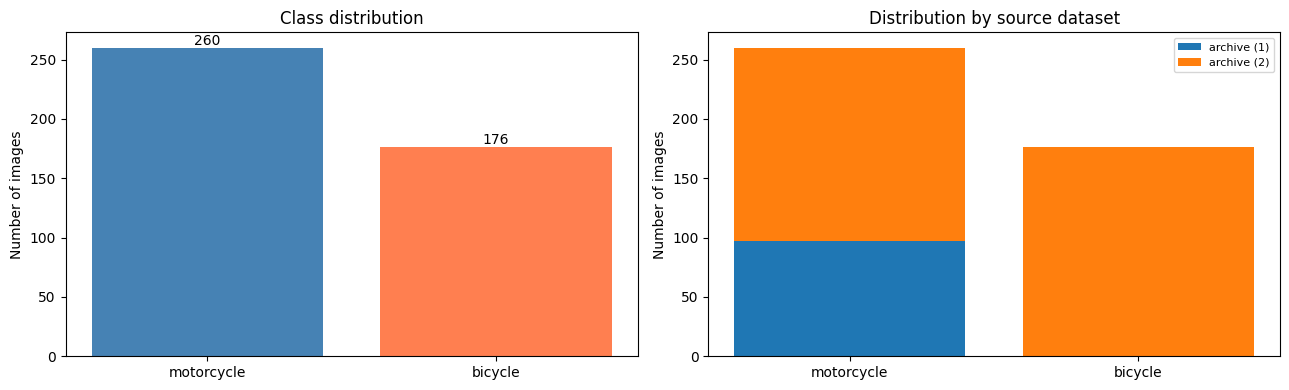

In [7]:
# Visualization: class distribution & per-source distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left plot: total image count per class
classes = list(stats.keys())
counts = [stats[c]["copied"] for c in classes]
axes[0].bar(classes, counts, color=["steelblue", "coral"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Number of images")
# Annotate each bar with its absolute count
for i, v in enumerate(counts):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# Right plot: stacked bars showing how each source dataset contributes to each class
all_sources = sorted({src for s in stats.values() for src in s["per_source"]})
bottom = [0] * len(classes)
for source in all_sources:
    # For every source, draw a layer on top of the previous one (stacked bar)
    values = [stats[c]["per_source"].get(source, 0) for c in classes]
    axes[1].bar(classes, values, bottom=bottom, label=source)
    bottom = [b + v for b, v in zip(bottom, values)]
axes[1].set_title("Distribution by source dataset")
axes[1].set_ylabel("Number of images")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


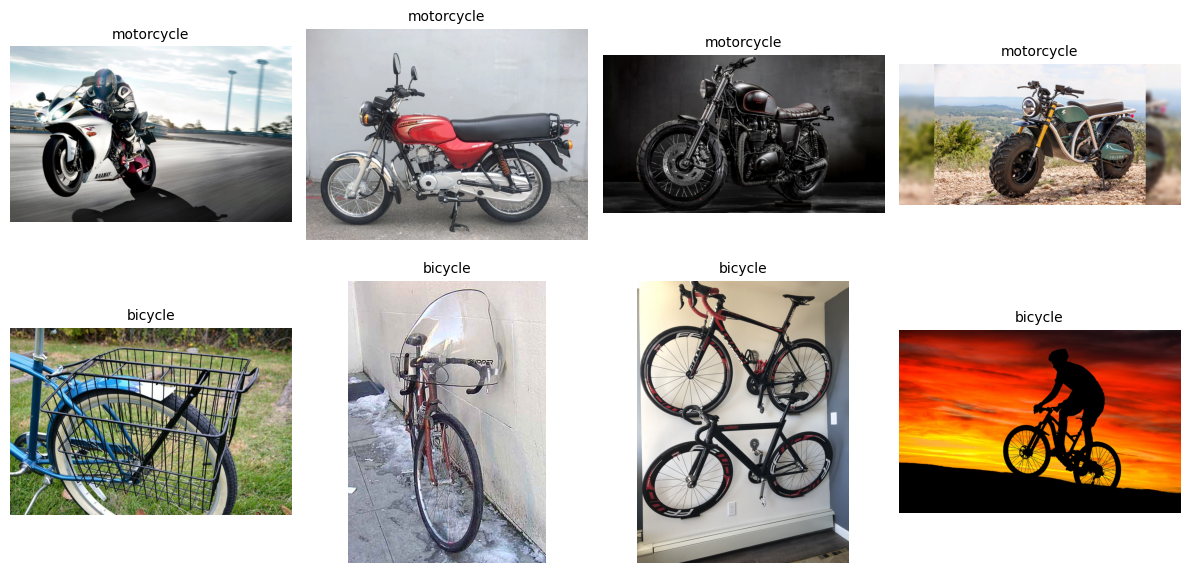

In [8]:
# Sample visualization: show a few images per class as a sanity check
import random

# Number of sample images to show per class
n_samples = 4
fig, axes = plt.subplots(len(classes), n_samples, figsize=(3 * n_samples, 3 * len(classes)))
# When there's only one class, plt.subplots returns a 1D array; wrap it for uniform indexing
if len(classes) == 1:
    axes = [axes]

# For each class, pick a random subset and display them in a grid row
for row, cls in enumerate(classes):
    images = list((OUTPUT_DIR / cls).iterdir())
    # random.sample without replacement; capped by how many images we actually have
    samples = random.sample(images, min(n_samples, len(images)))
    for col, img_path in enumerate(samples):
        with Image.open(img_path) as img:
            axes[row][col].imshow(img)
        axes[row][col].set_title(f"{cls}", fontsize=10)
        axes[row][col].axis("off")

plt.tight_layout()
plt.show()


## Done

`02_data_clean/` now contains the cleaned, de-duplicated dataset. Continue with **`project_pipeline.ipynb`** to build the train/val/test split and train the models.